<a href="https://colab.research.google.com/github/ksenofontov22/LAB1_data_analysis/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Постановка задачи**

Датасет "hourly_weаther_data" содержит данные о метеорологических и атмосферных условиях, собираемых датчиками с переодичностью в 1 час.
Сбор данных производился с 11 января 2011 года по 15 февраля 2014 года.

##**Заказчик**

Заказчиком анализа может являться служба прогноза погоды, служба мониторинга окружающей среды, научные отделы и лаборатории изучающие динамику атмосферы.


##**Возможные задачи ИАД**

*   категоризация погодных условий местности
*   сбор статистики по частоте погодных явлений
*   отслеживание стихийных бедствий

#2. **Паспорт датасета**


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv('/content/hourly_weather_data.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов\n\n')

#Преобразуем данные в более подходящие типы
for elem in df["time"]:
    elem = datetime.strptime(elem, "%Y-%m-%d %H:%M:%S");

df['time'] = df['time'].astype('datetime64[us]')
df['precipType'] = df['precipType'].astype('category')
df['curWeather'] = df['curWeather'].astype('category')
df['summary'] = df['summary'].astype('category')

print("Изначальная информация о столбцах и типах")
df.info()

# Статистика по числовым признакам
df.describe()

print("\n\nПреобразованные типы данных, с описанием")
descs = ["Видимость", "Направление ветра от севера в градусах", "Температура", "Дата и время измерения", "Точка росы", "Давление", "Ощущаемая температура", "Скорость ветра", "Тип осадков", "Текущая погода", "Влажность", "Итог, статус погоды на время замера"]
for i in range (len(df.columns)):
    print(f"{df.columns[i]:<20} - {str(df[df.columns[i]].dtype):<15} - {descs[i]}")
print()


Размер датасета: 21208 строк, 12 столбцов


Изначальная информация о столбцах и типах
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21208 entries, 0 to 21207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visibility           21208 non-null  float64       
 1   windBearing          21208 non-null  int64         
 2   temperature          21208 non-null  float64       
 3   time                 21208 non-null  datetime64[us]
 4   dewPoint             21208 non-null  float64       
 5   pressure             21195 non-null  float64       
 6   apparentTemperature  21208 non-null  float64       
 7   windSpeed            21208 non-null  float64       
 8   precipType           21208 non-null  category      
 9   curWeather           21204 non-null  category      
 10  humidity             21208 non-null  float64       
 11  summary              21208 non-null  category      
dtypes:

***3. Аудит качества данных***

3.1 Пропуски

In [120]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

print("Наиболее проблемные признаки: pressure и curWeather")
print("Доля пропусков у обоих признаков не критична для анализа")


Наиболее проблемные признаки: pressure и curWeather
Доля пропусков у обоих признаков не критична для анализа


3.2 Дубликаты

In [121]:
duplicates = df.duplicated().sum()
print(f'Полных дубликатов строк: {duplicates}')

Полных дубликатов строк: 28


3.3 Типические проблемы значений

In [122]:
print("Числовые признаки:")
numeric_cols = ['windSpeed', 'humidity']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"\tMin: {df[col].min()}\n\tMax: {df[col].max()}")
    print(f"\tMean: {df[col].mean():.2f}\n\tStd: {df[col].std():.2f}")
    print(f"\tМедиана: {df[col].median():.2f}")

    if col == 'Quantity':
        negative = (df[col] < 0).sum()
        print(f"\tОтрицательные значения (возвраты): {negative}")

    if col == 'UnitPrice':
        zero_price = (df[col] == 0).sum()
        negative_price = (df[col] < 0).sum()
        print(f"\tНулевые цены: {zero_price}")
        print(f"\tОтрицательные цены: {negative_price}")

print("\n\nКатегориальные признаки:")
cat_cols = ['precipType', 'curWeather', 'summary']
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"\tУникальных значений: {unique_count}")

    if col == 'summary':
        leading_spaces = df[col].astype(str).str.startswith(' ').sum()
        trailing_spaces = df[col].astype(str).str.endswith(' ').sum()
        print(f"\tЗначений с начальными пробелами: {leading_spaces}")
        print(f"\tЗначений с конечными пробелами: {trailing_spaces}")

#Устраним начальные и конечные пробелы в записи категориальных признаков
categ = ["precipType", "curWeather", "summary"]
for col in categ:
    df[col] = df[col].str.strip()

Числовые признаки:

windSpeed:
	Min: 0.04
	Max: 14.8
	Mean: 3.90
	Std: 2.03
	Медиана: 3.68

humidity:
	Min: 0.23
	Max: 1.0
	Mean: 0.78
	Std: 0.14
	Медиана: 0.81


Категориальные признаки:

precipType:
	Уникальных значений: 2

curWeather:
	Уникальных значений: 7

summary:
	Уникальных значений: 26
	Значений с начальными пробелами: 19
	Значений с конечными пробелами: 81


3.4 Выбросы

Найдём количество значений-выбросов в данных о скорости ветра
Выбросов по методу IQR: 342, 1.613% от общего кол-ва




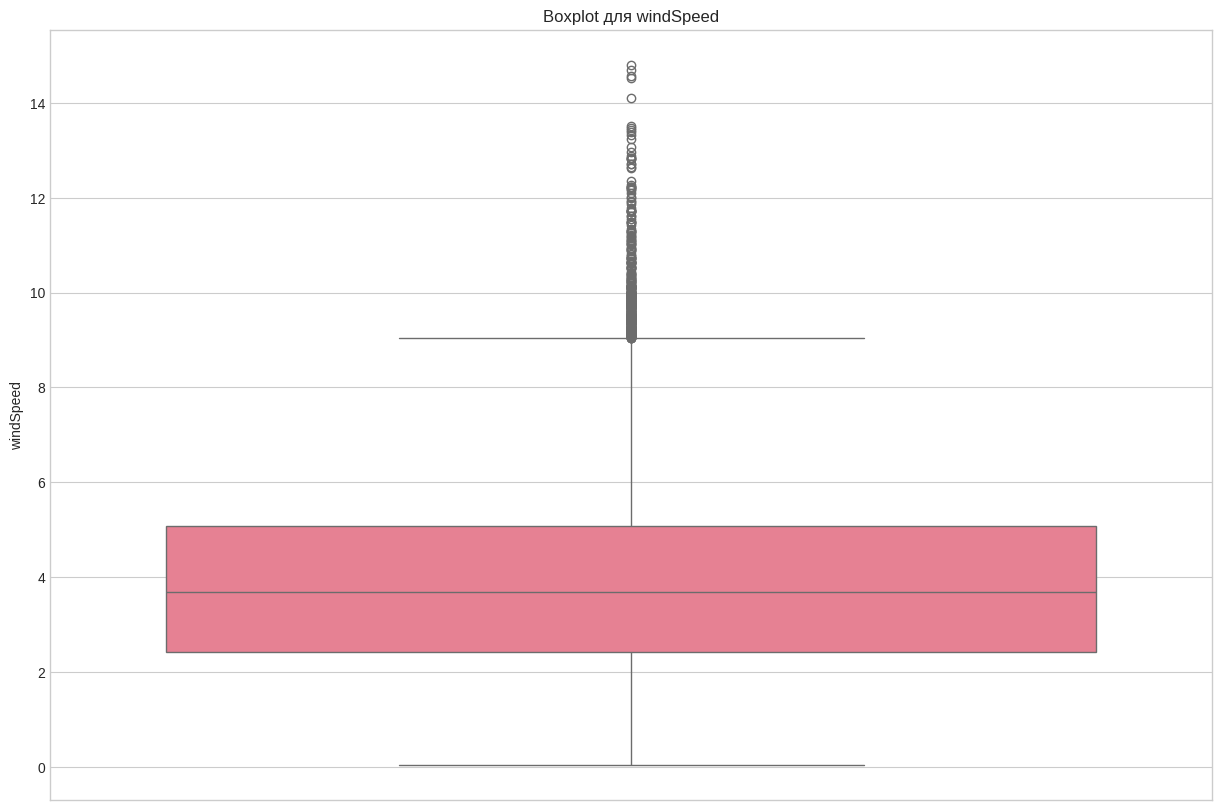


В зону наблюдения попали значения большие ~9 м/с
Такие значения обусловлены стихийными явлениями вроде гроз
По шкале Бофорта в регионе преобладает слабый ветер


In [123]:
column = 'windSpeed'
print("Найдём количество значений-выбросов в данных о скорости ветра")
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}, {len(outliers)/len(df["windSpeed"])*100:.3f}% от общего кол-ва\n\n')

# Визуализация
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column}')
plt.show()

print("\nВ зону наблюдения попали значения большие ~9 м/с")
print("Такие значения обусловлены стихийными явлениями вроде гроз")
print("По шкале Бофорта в регионе преобладает слабый ветер")

4. Мини-EDA (разведочный анализ)

4.1. Распределения признаков

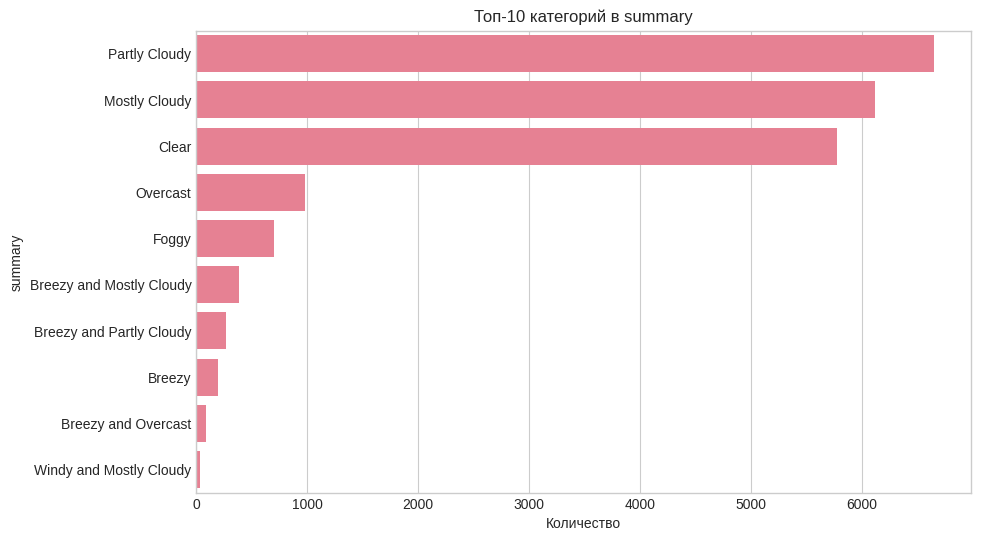


Комментарий к первому графику:
Типы погоды "Безоблачная погода", "частичная облачность", и "полная облачность" - составляет большую часть замеров 
Гипотеза: Самая распространённая погода в регионе - частичная облачность, ветренная погода редка.
Вопрос: Что влиет на отсутствие ветренной погоды в регионе?




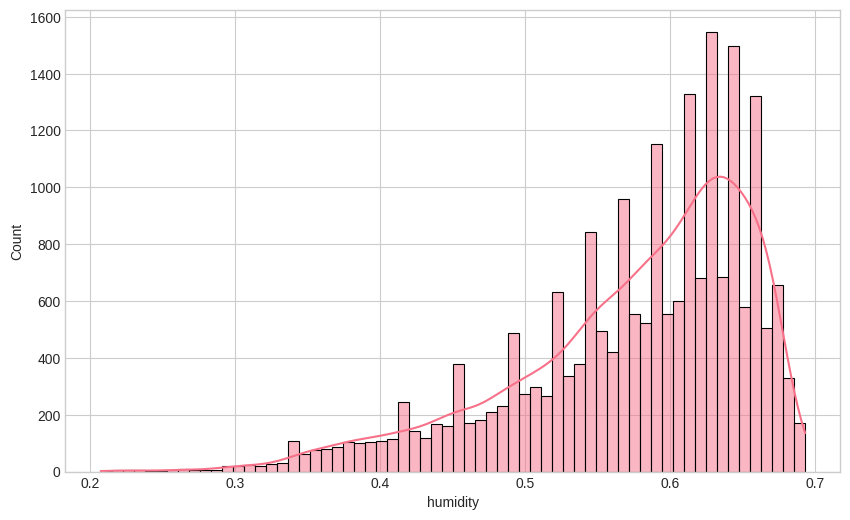


Комментарий к первому графику:
В регионе наблюдается повышенная влажность, кон
Гипотеза: регион находится около водоёма.
Вопрос: Что влияет на повышенную влажность в регионе?


In [124]:
plt.style.use('seaborn-v0_8-whitegrid')

cat_col = 'summary'

plt.figure(figsize=(10, 6))
top_categories = df[cat_col].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title(f'Топ-10 категорий в {cat_col}')
plt.xlabel('Количество')
plt.show()

print("""\nКомментарий к первому графику:
Типы погоды "Безоблачная погода", "частичная облачность", и "полная облачность" - составляет большую часть замеров
Гипотеза: Самая распространённая погода в регионе - частичная облачность, ветренная погода редка.
Вопрос: Что влиет на отсутствие ветренной погоды в регионе?
\n""")

plt.figure(figsize=(10, 6))
quantity_log = np.log1p(df['humidity'].abs())
sns.histplot(quantity_log, kde=True);

plt.show()

print("""\nКомментарий к первому графику:
В регионе наблюдается повышенная влажность, кон
Гипотеза: регион находится около водоёма.
Вопрос: Что влияет на повышенную влажность в регионе?""")


4.2. Зависимость между двумя признаками

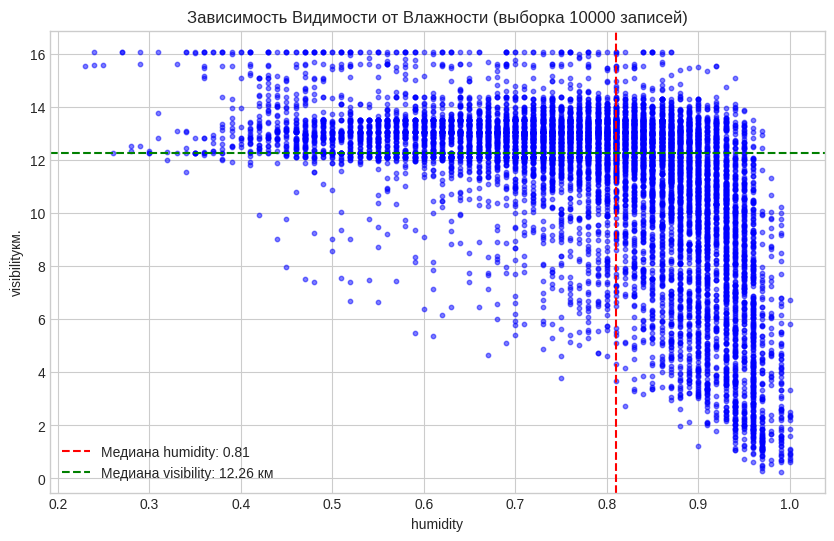


Комментарий к графику:
С повышением влажности разброс значений уровня видимости становится больше.
Гипотеза: повышенная влажность негативно влияет на видимость.
Вопрос: какие факторы помимо влажности влияют на образование туманов?


In [125]:
sample_size = min(10000, len(df))
sample_df = df.sample(sample_size, random_state=42)

of = "humidity"
fr = "visibility"

fig, axs = plt.subplots(1, 1, figsize=(10, 6))
scatter = axs.scatter(sample_df[of], sample_df[fr],
                     alpha=0.5, s=10, c='blue')
axs.set_title('Зависимость Видимости от Влажности (выборка 10000 записей)')
axs.set_xlabel(of)
axs.set_ylabel(fr + "км.")

# Добавляем линии средних
axs.axvline(df[of].median(), color='red', linestyle='--',
           label=f'Медиана humidity: {df[of].median():.2f}')
axs.axhline(df[fr].median(), color='green', linestyle='--',
           label=f'Медиана visibility: {df[fr].median():.2f} км')
axs.legend()

plt.show()

print("""\nКомментарий к графику:
С повышением влажности разброс значений уровня видимости становится больше.
Гипотеза: повышенная влажность негативно влияет на видимость.
Вопрос: какие факторы помимо влажности влияют на образование туманов?""")